# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

O dataset Auto MPG, pertence ao domínio da indústria automobilística e tem como objetivo principal a predição da eficiência de combustível de veículos (medida em milhas por galão, ou mpg). A base de dados contém informações sobre o consumo de combustível em ciclo urbano para diversos modelos de carros, apresentando atributos contínuos e discretos que descrevem a performance e a estrutura dos veículos, como a potência (horsepower), o peso (weight), a aceleração e o número de cilindros, além de dados como o ano do modelo, a origem geográfica e o nome do automóvel.

## <font color='green'>Preparação</font>

In [9]:
!pip install pandas scikit-learn ucimlrepo

In [10]:
#from ucimlrepo import fetch_ucirepo

import pandas as pd

colunas = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'car_name'
]
# Puxando o arquivo baixado
auto_mpg = pd.read_csv('auto-mpg.data', sep='\s+', names=colunas, na_values='?')


# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.drop(columns=['mpg', 'car_name'])

# y recebe apenas a coluna alvo
y = auto_mpg['mpg']

# Ver as primeiras linhas
display(X.head())

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8919/2911938053.py:10: SyntaxWarning: invalid escape sequence '\s'
  auto_mpg = pd.read_csv('auto-mpg.data', sep='\s+', names=colunas, na_values='?')


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504.0,12.0,70,1
1,8,350.0,165.0,3693.0,11.5,70,1
2,8,318.0,150.0,3436.0,11.0,70,1
3,8,304.0,150.0,3433.0,12.0,70,1
4,8,302.0,140.0,3449.0,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [11]:
df = X.copy()
df['mpg'] = y

total_antes = len(df)
df.dropna(inplace=True)
amostras_removidas = total_antes - len(df)

print(f"A quantidade de amostras removidas foi de: {amostras_removidas}")

# Voltando para X e y
X = df.drop('mpg', axis=1)
y = df['mpg']

A quantidade de amostras removidas foi de: 6


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

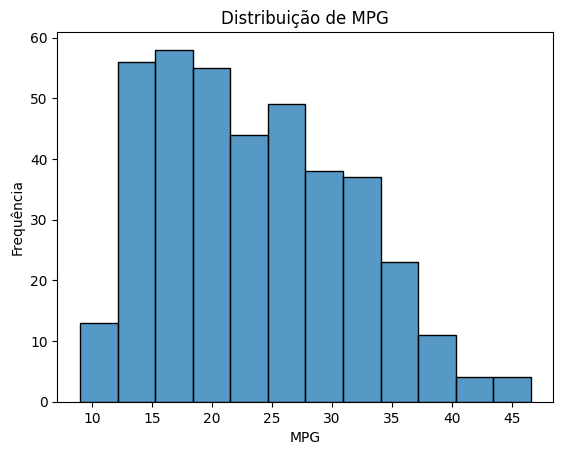

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y)
plt.title('Distribuição de MPG')
plt.xlabel('MPG')
plt.ylabel('Frequência')
plt.show()


### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A maioria dos veículos apresenta uma eficiência de combustível na faixa de 15 a 25 MPG. O consumo varia de aproximadamente 10 MPG (carros muito pouco eficientes) até cerca de 45 MPG (carros altamente eficientes). Nota-se que são poucos os veículos que conseguem ultrapassar a marca dos 35 MPG, evidenciando que os veículos representados tendem a ter um consumo mais elevado.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

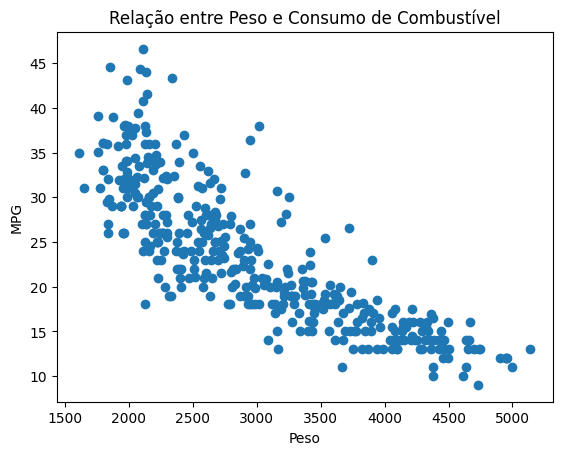

In [13]:
plt.scatter(X['weight'], y)
plt.title('Relação entre Peso e Consumo de Combustível')
plt.xlabel('Peso')
plt.ylabel('MPG')
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Pelo gráfico de dispersão, podemos observar que na média, quanto menor for o peso do veículo, menor será o consumo de combustível (Maior MPG = Menor Consumo) e vice-versa. Isso tem sentido na física, uma vez que veículos mais "pesados" exigem mais energia para estar em movimento. <br> A relação não é estritamente linear, pois apesar de uma reta poder aproximar de forma simples, uma curva descreveria de forma mais segura o comportameno real dos dados.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

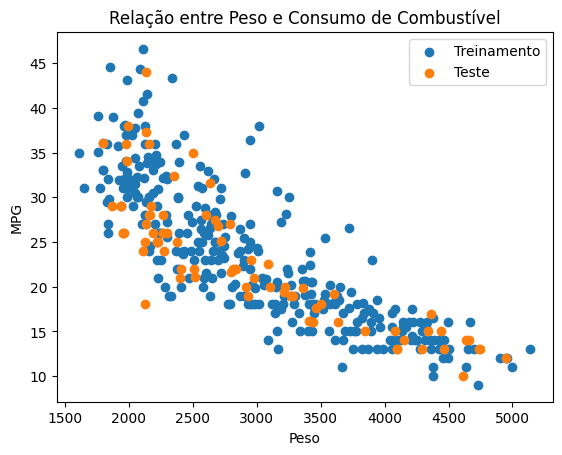

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X[['weight']], y, test_size=0.2, random_state=42)

plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)
plt.title('Relação entre Peso e Consumo de Combustível')
plt.xlabel('Peso')
plt.ylabel('MPG')
plt.legend(['Treinamento', 'Teste'])
plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim. Para ambos os casos (treinamento em azul e teste em laranja), os dados parecem seguir a representação original dos dados.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

O valor de r2 para o conjunto de treinamento foi de: 0.6982
O valor de r2 para o conjunto de teste foi de: 0.6533

O valor do MAE para o conjunto de treinamento foi de: 3.2855
O valor do MAE para o conjunto de teste foi de: 3.4641

O valor do MSE para o conjunto de treinamento foi de: 19.0451
O valor do MSE para o conjunto de teste foi de: 17.6934



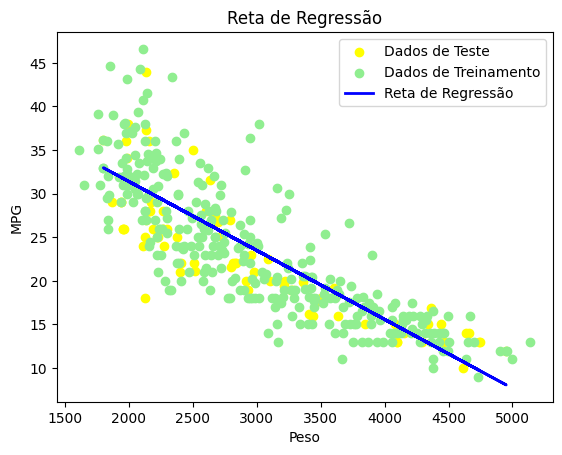

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_train_pred_line = model.predict(x_train)
y_test_pred_line = model.predict(x_test)

r2_train = r2_score(y_train, y_train_pred_line)
r2_test = r2_score(y_test, y_test_pred_line)

mae_train = mean_absolute_error(y_train, y_train_pred_line)
mae_test = mean_absolute_error(y_test, y_test_pred_line)

mse_train = mean_squared_error(y_train, y_train_pred_line)
mse_test = mean_squared_error(y_test, y_test_pred_line)

print(f"O valor de r2 para o conjunto de treinamento foi de: {r2_train:.4f}")
print(f"O valor de r2 para o conjunto de teste foi de: {r2_test:.4f}")
print()
print(f"O valor do MAE para o conjunto de treinamento foi de: {mae_train:.4f}")
print(f"O valor do MAE para o conjunto de teste foi de: {mae_test:.4f}")
print()
print(f"O valor do MSE para o conjunto de treinamento foi de: {mse_train:.4f}")
print(f"O valor do MSE para o conjunto de teste foi de: {mse_test:.4f}")
print()

# Para melhorar a visualização dos valores:

plt.scatter(x_test, y_test, color='yellow', label='Dados de Teste')
plt.scatter(x_train, y_train, color='lightgreen', label='Dados de Treinamento')
plt.plot(x_test, y_test_pred_line, color='blue', linewidth=2, label='Reta de Regressão')
plt.title('Reta de Regressão')
plt.xlabel('Peso')
plt.ylabel('MPG')
plt.legend()
plt.show()


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

O modelo sofre de underfitting. O R² abaixo de 0.70 no treino e a reta que não acompanha a curvatura dos dados indicam alto viés — o modelo é simples demais. Não há overfitting pois os erros de teste não são maiores que os de treino, mas o ajuste geral é insatisfatório.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

O valor de r2 para o conjunto de treinamento foi de: 0.7213
O valor de r2 para o conjunto de teste foi de: 0.6730

O valor do MAE para o conjunto de treinamento foi de: 3.0798
O valor do MAE para o conjunto de teste foi de: 3.1383

O valor do MSE para o conjunto de treinamento foi de: 17.5830
O valor do MSE para o conjunto de teste foi de: 16.6891



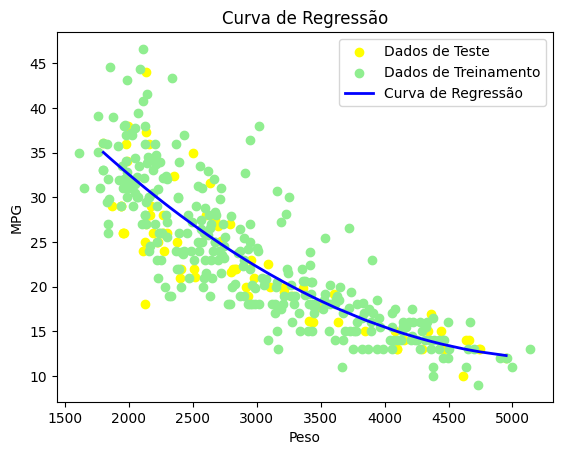

In [16]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline # Utilizado no ipynb do Professor
from sklearn.pipeline import Pipeline

model2 = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False), # Professor passou na teoria (já é feito pelo regressor)
    StandardScaler(),
    LinearRegression()
)

# Treinar
model2.fit(x_train, y_train)

# Predição

y_train_pred = model2.predict(x_train)
y_test_pred = model2.predict(x_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"O valor de r2 para o conjunto de treinamento foi de: {r2_train:.4f}")
print(f"O valor de r2 para o conjunto de teste foi de: {r2_test:.4f}")
print()
print(f"O valor do MAE para o conjunto de treinamento foi de: {mae_train:.4f}")
print(f"O valor do MAE para o conjunto de teste foi de: {mae_test:.4f}")
print()
print(f"O valor do MSE para o conjunto de treinamento foi de: {mse_train:.4f}")
print(f"O valor do MSE para o conjunto de teste foi de: {mse_test:.4f}")
print()

# Para melhorar a visualização dos valores:

plt.scatter(x_test, y_test, color='yellow', label='Dados de Teste')
plt.scatter(x_train, y_train, color='lightgreen', label='Dados de Treinamento')

# Sort utilizado somente para melhor visualização da curva:
x_test_sorted = x_test.sort_values(by='weight')
y_test_pred_sorted = model2.predict(x_test_sorted)

plt.plot(x_test_sorted, y_test_pred_sorted, color='blue', linewidth=2, label='Curva de Regressão')
plt.title('Curva de Regressão')
plt.xlabel('Peso')
plt.ylabel('MPG')
plt.legend()
plt.show()



### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo polinomial de grau 2 apresenta uma leve melhora em relação à regressão linear simples, porém ainda demonstra sinais de underfitting. <br>
Embora todas as métricas tenham melhorado, o ganho é pequeno. <br>
O underfitting tem duas possíveis causas combinadas: o modelo é simples demais para a relação não linear presente nos dados, e o conjunto de entrada possui apenas uma feature - que é o peso ('weight'), limitando a capacidade do modelo de capturar outros fatores que influenciam o consumo, como cilindros, potência e ano do veículo. Aumentar o grau do polinômio ou incluir novas features seriam formas iniciais de minimizar esse viés.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

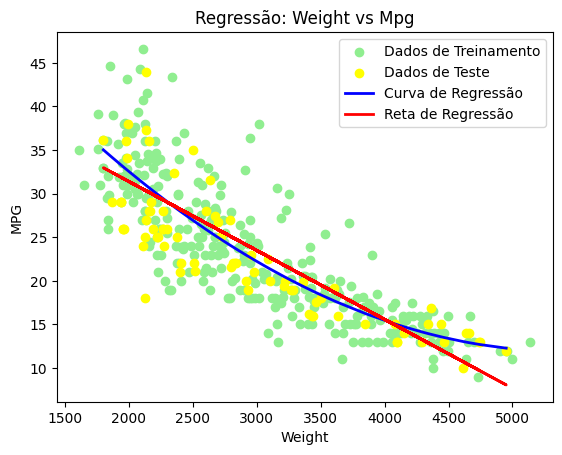

In [17]:
plt.scatter(x_train, y_train, color='lightgreen', label='Dados de Treinamento')
plt.scatter(x_test, y_test, color='yellow', label='Dados de Teste')
plt.plot(x_test_sorted, y_test_pred_sorted, color='blue', linewidth=2, label='Curva de Regressão')
plt.plot(x_test, y_test_pred_line, color='red', linewidth=2, label='Reta de Regressão')
plt.title('Regressão: Weight vs Mpg')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.legend()
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

O modelo polinomial (curva azul) se ajusta melhor aos dados. A curva acompanha a tendência de queda mais acentuada no início e mais suave no final, enquanto a reta vermelha subestima o MPG nos extremos e o superestima no meio.
A relação é não linear — como já analisado anteriormente, a queda no consumo é desproporcional nos pesos menores e se estabiliza nos pesos maiores, comportamento que uma reta não consegue capturar, mas uma curva de grau 2 aproxima melhor.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, os resultados são consistentes. <br>
A diferença entre avaliação visual e quantitativa é que o gráfico deixa claro onde os modelos erram (extremos e dispersão), enquanto as métricas mostram o quanto erram em média. Juntos, os dois tipos de avaliação dão uma visão mais completa do desempenho.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [18]:
# Usando todas as amostras:
model_overfit = make_pipeline(
    PolynomialFeatures(degree=20, include_bias=False),
    StandardScaler(),
    LinearRegression()
)

model_overfit.fit(x_train, y_train)

y_train_pred = model_overfit.predict(x_train)
y_test_pred  = model_overfit.predict(x_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test,  y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test  = mean_absolute_error(y_test,  y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_test_pred)

print("Para todas as amostras: ")
print(f"R2  treino: {r2_train:.4f}   |  R2  teste: {r2_test:.4f}")
print(f"MAE treino: {mae_train:.4f}   |  MAE teste: {mae_test:.4f}")
print(f"MSE treino: {mse_train:.4f}  |  MSE teste: {mse_test:.4f}")
print()

# Usando somente 40 amostras para treinar
x_tiny = x_train.iloc[:40]
y_tiny = y_train.iloc[:40]

model_overfit = make_pipeline(
    PolynomialFeatures(degree=20, include_bias=False),
    StandardScaler(),
    LinearRegression()
)

model_overfit.fit(x_tiny, y_tiny)


y_tiny_pred = model_overfit.predict(x_tiny)
y_test_pred = model_overfit.predict(x_test)
print("Para 40 amostras: ")
print(f"R2 treino: {r2_score(y_tiny, y_tiny_pred):.4f}")
print(f"R2 teste:  {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE treino: {mean_absolute_error(y_tiny, y_tiny_pred):.4f}")
print(f"MAE teste:  {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"MSE treino: {mean_squared_error(y_tiny, y_tiny_pred):.4f}")
print(f"MSE teste:  {mean_squared_error(y_test, y_test_pred):.4f}")

Para todas as amostras: 
R2  treino: 0.7330   |  R2  teste: 0.6614
MAE treino: 3.0324   |  MAE teste: 3.1653
MSE treino: 16.8469  |  MSE teste: 17.2814

Para 40 amostras: 
R2 treino: 0.7712
R2 teste:  -167383.0543
MAE treino: 2.4859
MAE teste:  340.4101
MSE treino: 12.6162
MSE teste:  8543379.7566


Para observar o overfitting na prática com o dataset disponível, foi necessário reduzir o conjunto de treinamento para poucas amostras. Isso se deve ao fato de que o dataset possui apenas uma feature (peso), e com muitas amostras de treino o número de parâmetros do polinômio é sempre muito menor que o número de amostras — impedindo o overfitting mesmo em graus altos como 15 ou 20.

Nesse caso, podemos observar o overfitting: o modelo memorizou os dados de treinamento incluindo seus ruídos. Podemos notar que as estatísticas de teste aumentaram drasticamente (R2 até ficou negativa), com estatísticas de treinamento satisfatórias - marcas claras de sobreajuste.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [19]:
from sklearn.linear_model import SGDRegressor

# Remover valores nulos
X_clean = X.dropna()
y_clean = df['weight'].loc[X_clean.index]

sgd = SGDRegressor(random_state=42)
sgd.fit(X_clean, y_clean)

y_pred_sgd = sgd.predict(X_clean)

print(f"R2:  {r2_score(y_clean, y_pred_sgd):.4f}")
print(f"MAE: {mean_absolute_error(y_clean, y_pred_sgd):.4f}")
print(f"MSE: {mean_squared_error(y_clean, y_pred_sgd):.4f}")

R2:  -66757858939431952471556096.0000
MAE: 6652934055780428.0000
MSE: 48041905108353102220569312493568.0000


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [20]:
sgd = make_pipeline(
    StandardScaler(),
    SGDRegressor(penalty=None,random_state=42)
)

sgd.fit(X_clean, y_clean)

y_pred_sgd = sgd.predict(X_clean)

print(f"R2:  {r2_score(y_clean, y_pred_sgd):.4f}")
print(f"MAE: {mean_absolute_error(y_clean, y_pred_sgd):.4f}")
print(f"MSE: {mean_squared_error(y_clean, y_pred_sgd):.4f}")


R2:  1.0000
MAE: 0.2775
MSE: 0.1401


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Sem Normalização: O modelo falhou completamente. Valores de R2 negativos e grandes e erros (MAE/MSE) enormes indicam que o modelo divergiu. Em vez de encontrar o mínimo da função de custo, o algoritmo "explodiu", gerando pesos que tendem ao infinito. <br> Normalização: O modelo obteve um desempenho excelente. Isso mostra que, ao colocar os dados na mesma escala, o algoritmo foi capaz de convergir para uma solução estável e precisa, reduzindo o erro médio. <br>

O funcionamento do Gradiente Descendente baseia-se na atualização dos pesos seguindo a direção oposta ao gradiente da função de custo.

Quando as variáveis têm escalas diferentes, as curvas de nível da função de custo (o "mapa" por onde o algoritmo caminha) tornam-se elipses extremamente alongadas.

Em superfícies "achatadas" (não normalizadas), o gradiente muitas vezes aponta para direções que não levam diretamente ao centro (mínimo), causando um comportamento de ziguezague ineficiente ou instabilidade.

Com a normalização, as curvas de nível tornam-se circulares. Isso permite que o vetor gradiente aponte diretamente para o mínimo, permitindo o uso de uma taxa de aprendizado mais alta e garantindo uma convergência rápida e estável.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [21]:
from sklearn.linear_model import Lasso
import pandas as pd

lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=1.0)
)

lasso.fit(X_clean, y_clean)

df_relevancia = pd.DataFrame({'Atributo': X_clean.columns, 'Coeficiente': lasso.named_steps['lasso'].coef_})

print(df_relevancia.sort_values(by='Coeficiente', ascending=False, key=abs))

       Atributo  Coeficiente
3        weight   847.269095
1  displacement     0.052896
0     cylinders     0.000000
2    horsepower     0.000000
4  acceleration    -0.000000
5    model_year    -0.000000
6        origin    -0.000000


Na Q16, sem normalização, o algoritmo (SGD) falhou ao lidar com escalas muito diferentes. Isso causou a "explosão" do gradiente, resultando em coeficientes infinitos ou nulos sem qualquer sentido físico. Na Q19, com o StandardScaler, todas as variáveis passaram a ter a mesma ordem de magnitude (média 0 e desvio padrão 1), permitindo que o modelo convergisse para valores reais que refletem a importância de cada atributo.

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [22]:
lasso01 = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)
lasso1 = make_pipeline(
    StandardScaler(),
    Lasso(alpha=1.0)
)
lasso5 = make_pipeline(
    StandardScaler(),
    Lasso(alpha=5.0)
)

lasso01 = lasso01.fit(X_clean, y_clean)
lasso1 = lasso1.fit(X_clean, y_clean)
lasso5 = lasso5.fit(X_clean, y_clean)

print("Lasso com alpha = 0.1:")

# Removendo coeficientes nulos:
print(X_clean.columns[lasso01.named_steps['lasso'].coef_ != 0])

print("Lasso com alpha = 1.0:")
print(X_clean.columns[lasso1.named_steps['lasso'].coef_ != 0])

print("Lasso com alpha = 5.0:")
print(X_clean.columns[lasso5.named_steps['lasso'].coef_ != 0])

Lasso com alpha = 0.1:
Index(['cylinders', 'displacement', 'horsepower', 'weight'], dtype='object')
Lasso com alpha = 1.0:
Index(['displacement', 'weight'], dtype='object')
Lasso com alpha = 5.0:
Index(['weight'], dtype='object')


À medida que o alpha aumenta, a complexidade do modelo diminui. Como o LASSO tem a característica única de deixar os coeficientes iguais a 0, quanto maior for o valor de alpha, menor o número de componentes presentes na análise final do modelo.